# Figures Generations Notebook
Author: Timothé LUCAS

In [109]:
# ==============================================================================

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Local deconvolution utilities
sys.path.append("../notebooks")
from util.utils import load_deconvolution_assets, compute_instantaneous_rate, correct_rnap_inactivation

# Configure publication-quality plot parameters (Nature/ACS guidelines)

plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

# ------------------------------------------------------------------------------


###  DECONVOLUTION / FITTING HYPERPARAMETERS


In [110]:
# ------------------------------------------------------------------------------

LAMBDA_REG = 0.5           # Tikhonov regularization factor
WINDOW_MIN = 65             # Savitzky-Golay integration window (min)

DATA_PATH = Path("../data/processed/TX_with_k_inact.csv")
ASSETS_PATH = Path("../notebooks/util/deconv_assets.pkl")

df = pd.read_csv(DATA_PATH)

_, f_kernel, alpha_slope, DT_MIN = load_deconvolution_assets(ASSETS_PATH)

# ------------------------------------------------------------------------------


Successfully loaded assets from: ../notebooks/util/deconv_assets.pkl


### Analysis architecture example:

In [111]:
#1. IMPORTS
#   │
#  ├── numpy
#   ├── pandas
#   ├── matplotlib
#   ├── scipy
#   └── utils
#          │
#          └── load_deconvolution_assets
#          └── compute_instantaneous_rate
#          └── correct_rnap_inactivation

#2. LOAD DATA
#   │
#   └── df
#
#3. LOAD DECONVOLUTION ASSETS
#   │
#   └── ASSETS_PATH
#          │
#          └── f_kernel
#          └── alpha_slope
#          └── DT_MIN
#
#4. SELECT WELLS / EXPERIMENTS
#   │
#   └── df_1
#
#5. ANALYZE WELLS
#   │
#   └── analyze_wells()
#          │
#          ├── RFU
#          │    ↓
#          │   deconvolution
#          │    ↓
#          │   RNA_cumulated
#          │    ↓
#          │   rate_instantaneous
#          │
#          └── k_inact_exp_mean
#               k_inact_exp_se
#                    ↓
#              RNAP correction
#                    ↓
#              rate_corrected
#
#6. RESULTS
#   │
#   └── results

#7. PLOTS / STATISTICS
#  └── utiliser results

# Figure 1: Topoisomerases effects on circular relaxed plasmid

### 1. Load datas from TX46 and TX47 Exp_ID


In [112]:
# ------------------------------------------------------------------------------

df_1 = df[
    (df["Exp_ID"].isin(["TL39 TX46", "TL39 TX47"])) &
    (df["[DNA] (nM)"] == 0.068) &
    (df["DNA Template"].str.contains("RX", na=False)) &
    (df["Well"] != "H10")
].copy()

print("=== TRANSCRIPTION DATASET SUMMARY ===")
print(f"Selected rows       : {len(df_1)}")
print(f"Total experiments   : {df_1['Exp_ID'].nunique()}")
print(
    f"Total wells analyzed: "
    f"{df_1[['Exp_ID', 'Well']].drop_duplicates().shape[0]}"
)

blank_df_1 = df[
    (df["Exp_ID"].isin(["TL39 TX46", "TL39 TX47"])) &
    (df["DNA Template"] == "BLANK")
].copy()

=== TRANSCRIPTION DATASET SUMMARY ===
Selected rows       : 1510
Total experiments   : 2
Total wells analyzed: 10


### 2. Deconvolution + rate computation + inactivation correction 


In [113]:
def analyze_wells(
    df,
    blank_df,
    f_kernel,
    alpha_slope,
    dt_min,
    exp_col="Exp_ID",
    well_col="Well",
    cycle_col="Cycle",
    time_col="time_min",
    signal_col="RFU",
    blank_template="BLANK",
    lambda_reg=0.5,
    window_min=50.0,
    polyorder=2,
    mode="interp",
):
    """
    Analyze selected transcription wells.

    Processing pipeline
    -------------------
    1. Match each experimental well with the BLANK of the same Exp_ID
       and Cycle.
    2. Subtract the cycle-specific BLANK RFU.
    3. Compute cumulative RNA and instantaneous transcription rate
       by Tikhonov deconvolution.
    4. Retrieve k_inact directly from the experimental dataset.
    5. Correct the instantaneous rate for RNAP inactivation.
    6. Preserve the main experimental metadata.

    Parameters
    ----------
    df : pandas.DataFrame
        Experimental wells to analyze.

    blank_df : pandas.DataFrame
        Original dataset containing BLANK wells.

    f_kernel : array-like
        Deconvolution kernel.

    alpha_slope : float
        RFU-to-RNA calibration slope.

    dt_min : float
        Time step in minutes.

    blank_template : str
        Value identifying the BLANK DNA template.

    mode : str
        Savitzky-Golay edge handling.
        "interp" reproduces the previous analysis behavior.
    """

    # ==================================================================
    # 1. VALIDATION
    # ==================================================================

    required_columns = {
        exp_col,
        well_col,
        cycle_col,
        time_col,
        signal_col,
        "DNA Template",
        "[DNA] (nM)",
        "[RNAP] (nM)",
        "Gyr (U)",
        "TopoI (U)",
        "k_inact_exp_mean",
        "k_inact_exp_se",
    }

    missing = required_columns - set(df.columns)

    if missing:
        raise ValueError(
            f"Missing required columns in df: {sorted(missing)}"
        )

    blank_required = {
        exp_col,
        cycle_col,
        signal_col,
        "DNA Template",
    }

    missing_blank = blank_required - set(blank_df.columns)

    if missing_blank:
        raise ValueError(
            f"Missing required columns in blank_df: "
            f"{sorted(missing_blank)}"
        )

    if not np.isfinite(alpha_slope):
        raise ValueError(
            f"alpha_slope must be finite. Got {alpha_slope}"
        )

    if not np.isfinite(dt_min) or dt_min <= 0:
        raise ValueError(
            f"dt_min must be positive. Got {dt_min}"
        )

    f_kernel = np.asarray(f_kernel, dtype=float)

    if f_kernel.ndim != 1 or len(f_kernel) == 0:
        raise ValueError(
            "f_kernel must be a non-empty 1D array."
        )

    # ==================================================================
    # 2. EXTRACT BLANK WELLS
    # ==================================================================

    blanks = blank_df[
        blank_df["DNA Template"].eq(blank_template)
    ].copy()

    if blanks.empty:
        raise ValueError(
            f"No BLANK wells found with "
            f"DNA Template == '{blank_template}'."
        )

    # --------------------------------------------------------------
    # Check one BLANK per Exp_ID
    # --------------------------------------------------------------

    blank_counts = (
        blanks.groupby(exp_col)[well_col]
        .nunique()
    )

    multiple_blanks = blank_counts[blank_counts > 1]

    if not multiple_blanks.empty:
        raise ValueError(
            "More than one BLANK well found for: "
            f"{multiple_blanks.index.tolist()}"
        )

    # --------------------------------------------------------------
    # Build lookup: Exp_ID + Cycle -> blank RFU
    # --------------------------------------------------------------

    blank_lookup = blanks[
        [exp_col, cycle_col, signal_col]
    ].copy()

    duplicate_blank_cycles = (
        blank_lookup
        .groupby([exp_col, cycle_col])
        .size()
    )

    duplicates = duplicate_blank_cycles[
        duplicate_blank_cycles > 1
    ]

    if not duplicates.empty:
        raise ValueError(
            "Multiple BLANK RFU values found for some "
            "Exp_ID / Cycle combinations."
        )

    blank_lookup = blank_lookup.rename(
        columns={
            signal_col: "RFU_blank"
        }
    )

    # ==================================================================
    # 3. RESULTS CONTAINER
    # ==================================================================

    results = []

    # ==================================================================
    # 4. ANALYZE EACH WELL
    # ==================================================================

    for (exp_id, well), well_df in df.groupby(
        [exp_col, well_col],
        sort=False
    ):

        # --------------------------------------------------------------
        # Prepare well trace
        # --------------------------------------------------------------

        trace = (
            well_df[
                [
                    exp_col,
                    well_col,
                    cycle_col,
                    time_col,
                    signal_col,
                    "DNA Template",
                    "[DNA] (nM)",
                    "[RNAP] (nM)",
                    "Gyr (U)",
                    "TopoI (U)",
                    "k_inact_exp_mean",
                    "k_inact_exp_se",
                ]
            ]
            .dropna(subset=[cycle_col, time_col, signal_col])
            .sort_values(cycle_col)
            .copy()
        )

        if len(trace) < 3:
            print(
                f"Skipping {exp_id} / {well}: "
                f"only {len(trace)} valid points."
            )
            continue

        # --------------------------------------------------------------
        # Add corresponding BLANK
        # --------------------------------------------------------------

        trace = trace.merge(
            blank_lookup,
            on=[exp_col, cycle_col],
            how="left",
            validate="many_to_one",
        )

        missing_blank = trace["RFU_blank"].isna()

        if missing_blank.any():
            missing_cycles = (
                trace.loc[missing_blank, cycle_col]
                .tolist()
            )

            raise ValueError(
                f"{exp_id} / {well}: missing BLANK values "
                f"for cycles {missing_cycles}"
            )

        # --------------------------------------------------------------
        # Blank-corrected RFU
        # --------------------------------------------------------------

        trace["RFU_corrected"] = (
            trace[signal_col]
            - trace["RFU_blank"]
        )

        # --------------------------------------------------------------
        # Time and signal
        # --------------------------------------------------------------

        time_min = trace[time_col].to_numpy(dtype=float)

        rfu_corrected = (
            trace["RFU_corrected"]
            .to_numpy(dtype=float)
        )

        # --------------------------------------------------------------
        # Check time axis
        # --------------------------------------------------------------

        if np.any(np.diff(time_min) <= 0):
            raise ValueError(
                f"{exp_id} / {well}: "
                "time values must be strictly increasing."
            )

        # ==================================================================
        # 5. EXPERIMENTAL METADATA
        # ==================================================================

        metadata_columns = [
            "DNA Template",
            "[DNA] (nM)",
            "[RNAP] (nM)",
            "Gyr (U)",
            "TopoI (U)",
        ]

        metadata = {}

        for column in metadata_columns:

            values = trace[column].dropna().unique()

            if len(values) == 0:
                metadata[column] = np.nan

            elif len(values) > 1:
                raise ValueError(
                    f"{exp_id} / {well}: multiple values for "
                    f"{column}: {values}"
                )

            else:
                metadata[column] = values[0]

        # ==================================================================
        # 6. k_inact
        # ==================================================================

        k_values = (
            trace["k_inact_exp_mean"]
            .dropna()
            .unique()
        )

        if len(k_values) != 1:
            raise ValueError(
                f"{exp_id} / {well}: expected exactly one "
                f"k_inact_exp_mean, found {k_values}"
            )

        k_inact = float(k_values[0])

        k_se_values = (
            trace["k_inact_exp_se"]
            .dropna()
            .unique()
        )

        if len(k_se_values) > 1:
            raise ValueError(
                f"{exp_id} / {well}: multiple "
                f"k_inact_exp_se values found."
            )

        k_inact_se = (
            float(k_se_values[0])
            if len(k_se_values) == 1
            else None
        )

        # ==================================================================
        # 7. DECONVOLUTION
        # ==================================================================

        rna_cumulated, rate = compute_instantaneous_rate(
            rfu_signal=rfu_corrected,
            f_kernel=f_kernel,
            alpha_slope=alpha_slope,
            dt_min=dt_min,
            lambda_reg=lambda_reg,
            window_min=window_min,
            polyorder=polyorder,
            mode=mode,
        )

        # ==================================================================
        # 8. RNAP INACTIVATION CORRECTION
        # ==================================================================

        rate_corrected, rate_corrected_se = (
            correct_rnap_inactivation(
                rate=rate,
                time_min=time_min,
                k_inact=k_inact,
                k_inact_se=k_inact_se,
            )
        )

        correction_factor = np.exp(
            k_inact * time_min
        )

        # ==================================================================
        # 9. STORE RESULTS
        # ==================================================================

        well_results = pd.DataFrame({

            # ----------------------------------------------------------
            # Experimental identifiers
            # ----------------------------------------------------------

            exp_col: exp_id,
            well_col: well,
            cycle_col: trace[cycle_col].to_numpy(),

            # ----------------------------------------------------------
            # Experimental conditions
            # ----------------------------------------------------------

            "DNA Template": metadata["DNA Template"],
            "[DNA] (nM)": metadata["[DNA] (nM)"],
            "[RNAP] (nM)": metadata["[RNAP] (nM)"],
            "Gyr (U)": metadata["Gyr (U)"],
            "TopoI (U)": metadata["TopoI (U)"],

            # ----------------------------------------------------------
            # Raw / corrected signal
            # ----------------------------------------------------------

            time_col: time_min,
            "RFU_raw": trace[signal_col].to_numpy(),
            "RFU_blank": trace["RFU_blank"].to_numpy(),
            "RFU_corrected": rfu_corrected,

            # ----------------------------------------------------------
            # Deconvolution
            # ----------------------------------------------------------

            "RNA_cumulated": rna_cumulated,
            "rate_instantaneous": rate,

            # ----------------------------------------------------------
            # RNAP inactivation
            # ----------------------------------------------------------

            "k_inact": k_inact,
            "k_inact_se": (
                k_inact_se
                if k_inact_se is not None
                else np.nan
            ),

            "RNAP_correction_factor": correction_factor,

            "rate_corrected": rate_corrected,
            "rate_corrected_se": rate_corrected_se,
        })

        results.append(well_results)

    # ==================================================================
    # 10. COMBINE RESULTS
    # ==================================================================

    if not results:
        raise ValueError(
            "No wells could be analyzed successfully."
        )

    return pd.concat(
        results,
        ignore_index=True
    )

In [116]:
# ==============================================================================
# ANALYZE SELECTED WELLS
# ==============================================================================

results_1 = analyze_wells(
    df=df_1,
    blank_df=blank_df_1,
    f_kernel=f_kernel,
    alpha_slope=alpha_slope,
    dt_min=DT_MIN,
    lambda_reg=LAMBDA_REG,
    window_min=WINDOW_MIN,
    polyorder=2,
    mode="interp",
)
print(results_1)

         Exp_ID Well  Cycle DNA Template  [DNA] (nM)  [RNAP] (nM)  Gyr (U)  \
0     TL39 TX46   F4      1   RX OPPO #2       0.068        340.0      0.0   
1     TL39 TX46   F4      2   RX OPPO #2       0.068        340.0      0.0   
2     TL39 TX46   F4      3   RX OPPO #2       0.068        340.0      0.0   
3     TL39 TX46   F4      4   RX OPPO #2       0.068        340.0      0.0   
4     TL39 TX46   F4      5   RX OPPO #2       0.068        340.0      0.0   
...         ...  ...    ...          ...         ...          ...      ...   
1505  TL39 TX47   D8    147   RX OPPO #2       0.068        340.0      2.0   
1506  TL39 TX47   D8    148   RX OPPO #2       0.068        340.0      2.0   
1507  TL39 TX47   D8    149   RX OPPO #2       0.068        340.0      2.0   
1508  TL39 TX47   D8    150   RX OPPO #2       0.068        340.0      2.0   
1509  TL39 TX47   D8    151   RX OPPO #2       0.068        340.0      2.0   

      TopoI (U)  time_min      RFU_raw    RFU_blank  RFU_correc

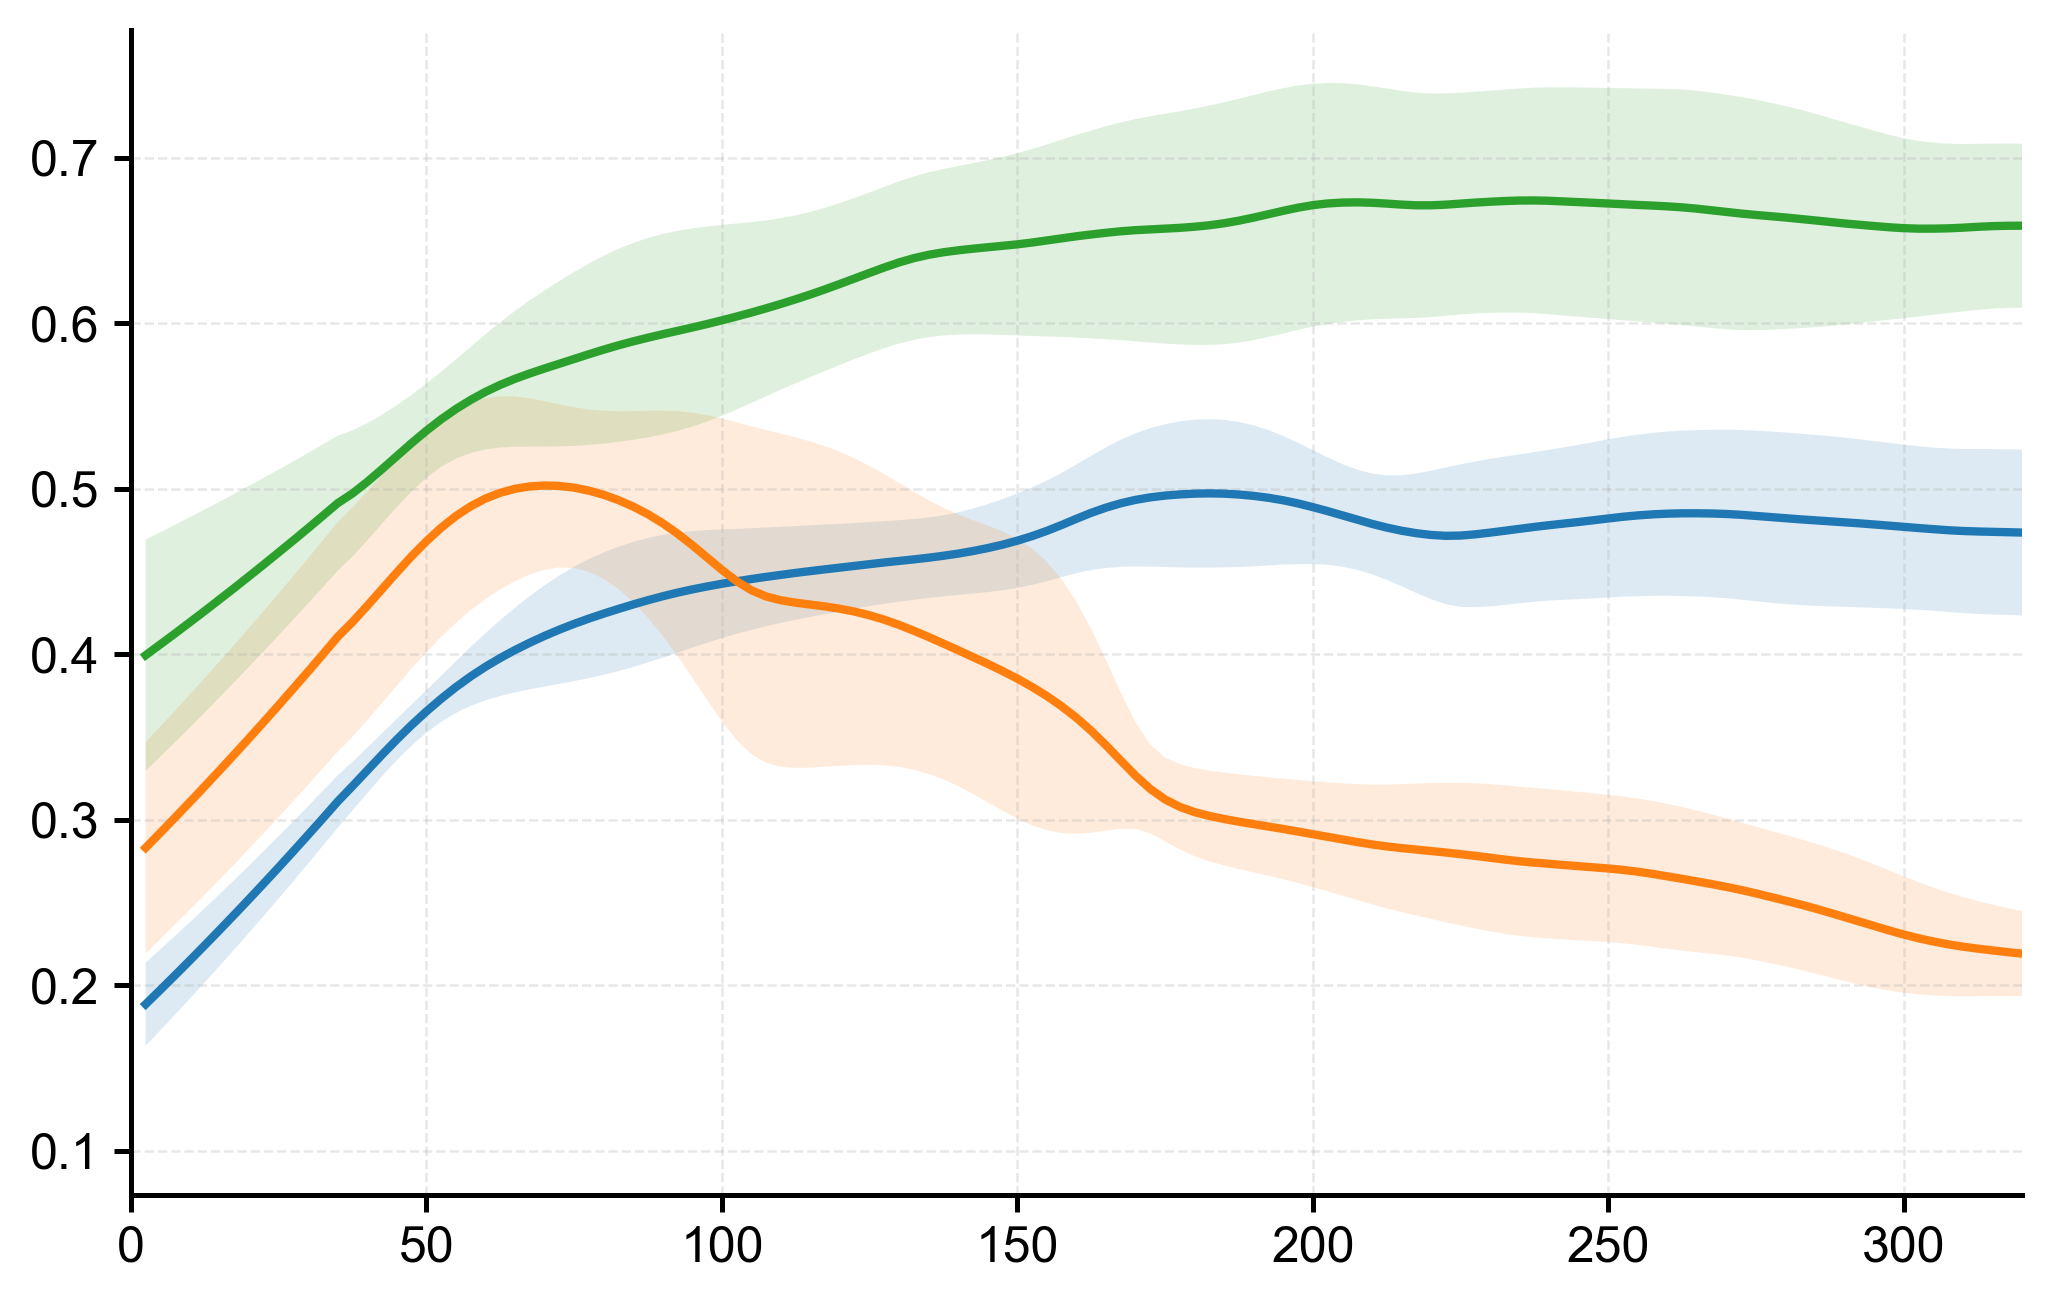

In [117]:
fig, ax = plt.subplots(figsize=(7, 4.5))

plot_stats = (
    results_1
    .groupby(["Gyr (U)", "TopoI (U)", "time_min","DNA Template", "[DNA] (nM)", "[RNAP] (nM)"])
    .agg(
        mean=("rate_corrected", "mean"),
        std=("rate_corrected", "std"),
        count=("rate_corrected", "count"),
    )
    .reset_index()
)

for (gyr, topoi), d in plot_stats.groupby(["Gyr (U)", "TopoI (U)"]):
    d = d.sort_values("time_min")
    x, y, sd = d["time_min"], d["mean"], d["std"]

    ax.plot(x, y, lw=2)
    ax.fill_between(x, y - sd, y + sd, alpha=0.15, lw=0)

ax.set_xlim(0, 320)
ax.grid(True, ls="--", lw=0.6, alpha=0.3)

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(direction="out", width=1.2, length=4)

plt.tight_layout()
plt.show()